In [2]:
import os
import argparse
import json
import numpy as np
import xarray as xr
import cftime
import xskillscore as xs
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl

In [3]:
class TauClimatologyPlotter:
    def __init__(self, exp_dict, save_dir=None, ref_name='ERA5'):
        self.exp_dict = exp_dict
        self.save_dir = save_dir
        self.ref_name = ref_name
        self.season_order = ['ANN', 'DJF', 'MAM', 'JJA', 'SON']
        self.unit_map = {
            'tauu': 'tauu (10⁻² N m$^{-2}$)',
            'tauv': 'tauv (10⁻² N m$^{-2}$)',
            'tau_mag': 'tau_mag (10⁻² N m$^{-2}$)'
        }

    def _normalize_longitude(self, da):
        if 'lon' in da.coords:
            da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
            da = da.sortby(da.lon)
        return da

    def _load_components(self, tauu_path, tauv_path):
        ds_tauu = xr.open_dataset(tauu_path, decode_times=True)
        ds_tauv = xr.open_dataset(tauv_path, decode_times=True)

        tauu_var = [v for v in ds_tauu.data_vars if 'tau' in v.lower() and ds_tauu[v].dims[0] == 'time'][0]
        tauv_var = [v for v in ds_tauv.data_vars if 'tau' in v.lower() and ds_tauv[v].dims[0] == 'time'][0]

        tauu = ds_tauu[tauu_var] * 100
        tauv = ds_tauv[tauv_var] * 100
        return tauu, tauv

    def _compute_seasonal_means(self, da):
        da = da.copy()
        da['time'] = xr.cftime_range(start="2000-01-01", periods=12, freq='MS')
        return {
            'ANN': da.mean(dim='time', skipna=True),
            **{
                s: da.sel(time=da['time'].dt.season == s).mean(dim='time', skipna=True)
                for s in ['DJF', 'MAM', 'JJA', 'SON']
            }
        }

    def _compute_all_fields(self, var_name):
        seasonal_data = {}
        for exp, paths in self.exp_dict.items():
            tauu, tauv = self._load_components(paths['tauu'], paths['tauv'])
            tauu_season = self._compute_seasonal_means(tauu)
            tauv_season = self._compute_seasonal_means(tauv)

            if var_name == 'tauu':
                seasonal_data[exp] = tauu_season
            elif var_name == 'tauv':
                seasonal_data[exp] = tauv_season
            elif var_name == 'tau_mag':
                seasonal_data[exp] = {
                    s: np.sqrt(tauu_season[s]**2 + tauv_season[s]**2).assign_attrs(name='tau_mag')
                    for s in self.season_order
                }
            else:
                raise ValueError(f"Unknown variable: {var_name}")
        return seasonal_data

    def plot_variable(self, var_name='tau_mag', cmap1='viridis', cmap2='RdBu_r',
                      vmin1=None, vmax1=None, vmin2=None, vmax2=None,
                      levels1=None, levels2=None, center_zero=True,
                      fontz=11, fig_size=(20, 12)):
        ref = self.ref_name
        all_exps = list(self.exp_dict.keys())
        model_exps = [exp for exp in all_exps if exp != ref]
        nrow, ncol = len(model_exps) + 1, len(self.season_order)

        ref_data = self._compute_all_fields(var_name)[ref]
        model_data = self._compute_all_fields(var_name)

        lat = ref_data['ANN']['lat']
        weights = np.cos(np.deg2rad(lat))
        weights = weights / weights.mean()
        weights = weights.broadcast_like(ref_data['ANN'])

        fig, axes = plt.subplots(nrow, ncol, figsize=fig_size,
                                 subplot_kw={'projection': ccrs.PlateCarree()},
                                 constrained_layout=False)

        if nrow == 1:
            axes = np.expand_dims(axes, axis=0)
        if ncol == 1:
            axes = np.expand_dims(axes, axis=1)

        im_handles = []

        for i, exp in enumerate([ref] + model_exps):
            row_ims = []

            for j, season in enumerate(self.season_order):
                if exp == ref:
                    plot_data = ref_data[season]
                    cmap = cmap1
                    levels = levels1
                    extend = 'both'
                else:
                    plot_data = model_data[exp][season] - ref_data[season]
                    cmap = cmap2
                    levels = levels2
                    extend = 'both'

                vmin, vmax = levels[0], levels[-1]
                        
                norm = None
                if levels is not None:
                    norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=plt.get_cmap(cmap).N)

                lat = plot_data['lat'].values
                lon = plot_data['lon'].values
                ax = axes[i, j]
                ax.set_global()
                ax.coastlines()
                ax.add_feature(cfeature.BORDERS, linewidth=0.3)
                gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.5)
                gl.top_labels = False
                gl.right_labels = False
                gl.left_labels = True
                gl.bottom_labels = True
                gl.xlabel_style = {'size': fontz * 0.85}
                gl.ylabel_style = {'size': fontz * 0.85}

                im = ax.contourf(lon, lat, plot_data, transform=ccrs.PlateCarree(),
                                 levels=levels if levels is not None else 20, cmap=cmap,
                                 vmin=vmin, vmax=vmax, norm=norm, extend=extend)

                row_ims.append(im)

                if i == 0:
                    ax.set_title(f"{exp} ({season})", fontsize=fontz)
                else:
                    ax.set_title(f"{exp} - {ref} ({season})", fontsize=fontz)

                if exp != ref:
                    bias = model_data[exp][season] - ref_data[season]
                    ref_vals = ref_data[season]
                    rmse = float(xs.rmse(model_data[exp][season], ref_vals, dim=['lat', 'lon'], weights=weights))
                    pcor = float(xs.pearson_r(model_data[exp][season], ref_vals, dim=['lat', 'lon'], weights=weights))
                    ax.text(0.98, 0.02, f"RMSE={rmse:.2f}\nPCOR={pcor:.2f}",
                            transform=ax.transAxes, fontsize=fontz * 0.90, va='bottom', ha='right',
                            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

            im_for_cbar = next((im for im in row_ims if im is not None), None)
            im_handles.append(im_for_cbar)

        row_height = 1.0 / nrow
        bar_height = 0.01  # thinner colorbar
        bar_pad = 0.035    # a bit more space above plots
        
        for i, im in enumerate(im_handles):
            row_bottom = 1.0 - (i + 1) * 0.22 + i*bar_pad 
            cax = fig.add_axes([
                0.1,
                row_bottom,
                0.6,
                bar_height
            ])
            label = self.unit_map.get(var_name, var_name)
            if center_zero and i > 0:
                label = f"Bias ({label})"
            cbar = fig.colorbar(im, cax=cax, orientation='horizontal', extend='both')
            if hasattr(im, 'levels'):
                cbar.set_ticks(im.levels)
            cbar.set_label(label, fontsize=fontz)
            cbar.ax.tick_params(labelsize=fontz * 0.95)

        fig.subplots_adjust(left=0.05, right=0.95, top=0.94, bottom=0.08, wspace=0.2, hspace=0.15)

        if self.save_dir:
            os.makedirs(self.save_dir, exist_ok=True)
            fname = f"{self.save_dir}/tau_bias_grid_{var_name}.png"
            plt.savefig(fname, dpi=150)
            print(f"[INFO] Saved {fname}")

        plt.show()

/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tauu' has multiple fill values {np.float32(-9999.0), np.float32(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tauv' has multiple fill values {np.float32(-9999.0), np.float32(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tauu' has multiple fill values {np.float32(-9999.0), np.float32(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tauv' has multiple

[INFO] Saved ./amip_model_vs_obs_1985-2014/tau_bias_grid_tauu.png


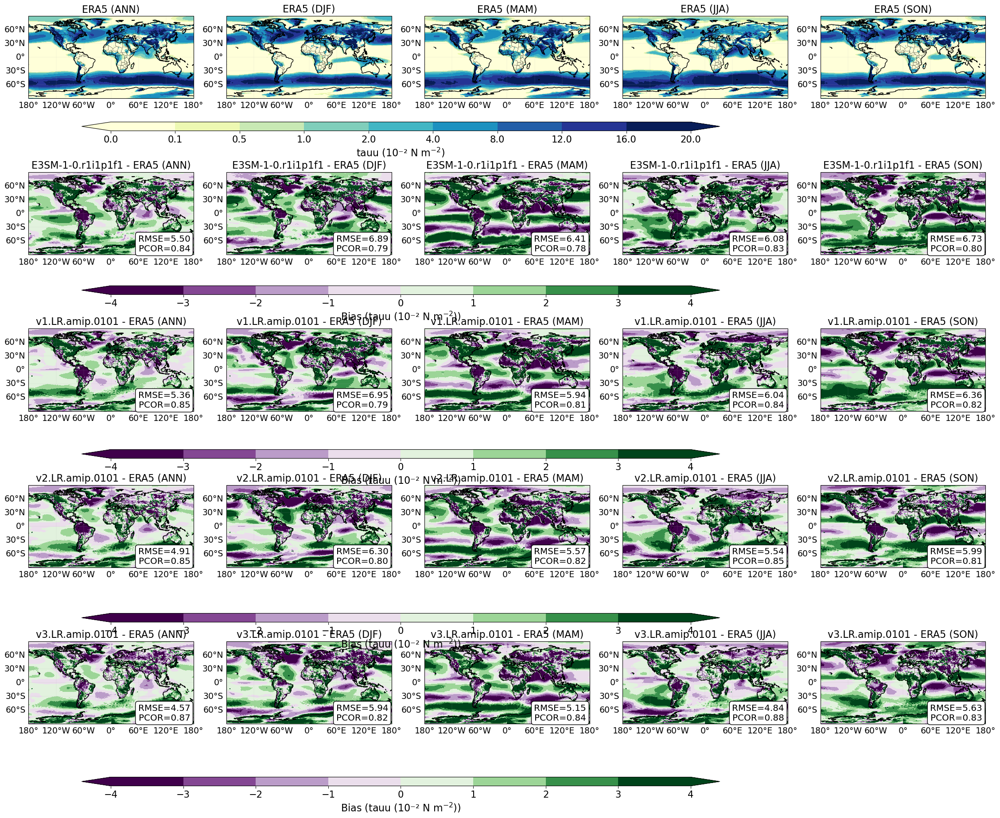

/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tauu' has multiple fill values {np.float32(-9999.0), np.float32(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tauv' has multiple fill values {np.float32(-9999.0), np.float32(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tauu' has multiple fill values {np.float32(-9999.0), np.float32(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tauv' has multiple

[INFO] Saved ./amip_model_vs_obs_1985-2014/tau_bias_grid_tauv.png


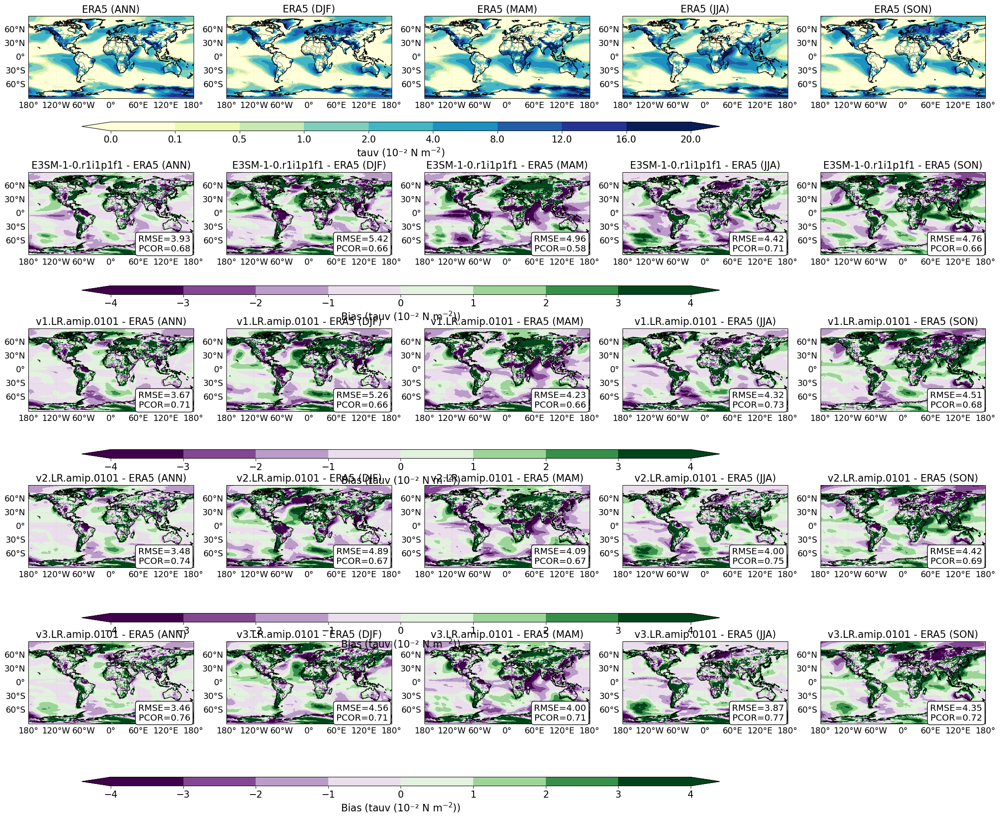

/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tauu' has multiple fill values {np.float32(-9999.0), np.float32(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tauv' has multiple fill values {np.float32(-9999.0), np.float32(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tauu' has multiple fill values {np.float32(-9999.0), np.float32(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tauv' has multiple

[INFO] Saved ./amip_model_vs_obs_1985-2014/tau_bias_grid_tau_mag.png


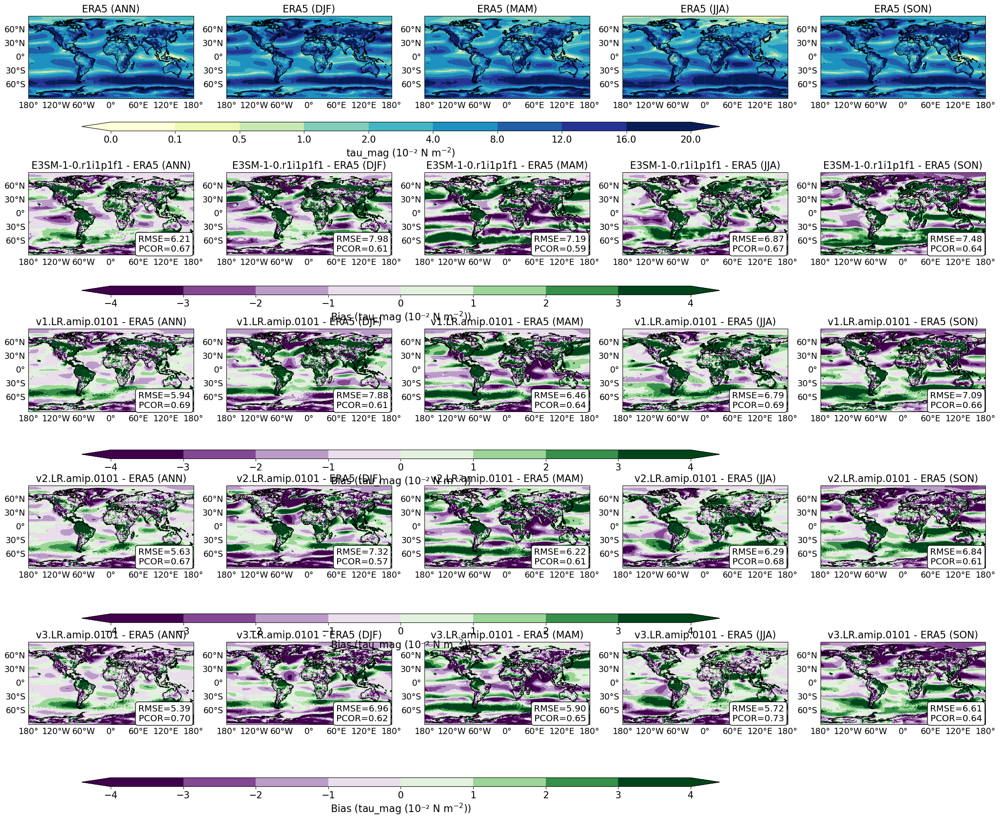

In [164]:
if __name__ == "__main__":
    outdir = "./amip_model_vs_obs_1985-2014"
    ref_name = "ERA5"

    exp_dict={
        'ERA5':{
            'tauu':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/observations/clim/v20240701/tauu/observations.historical.ERA5.en00.mon.tauu.198501-201412.AC.v20240701.nc',
            'tauv':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/observations/clim/v20240701/tauv/observations.historical.ERA5.en00.mon.tauv.198501-201412.AC.v20240701.nc'
        },
        'E3SM-1-0.r1i1p1f1':{
            'tauu':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/clim/cmip6/historical/v20240701/tauu/cmip6.historical.E3SM-1-0.r1i1p1f1.mon.tauu.198501-201412.AC.v20240701.nc',
            'tauv':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/clim/cmip6/historical/v20240701/tauv/cmip6.historical.E3SM-1-0.r1i1p1f1.mon.tauv.198501-201412.AC.v20240701.nc'
        },
        'v1.LR.amip.0101':{
            'tauu':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/clim/e3sm/amip/v20240701/tauu/e3sm.amip.v1-LR.0101.mon.tauu.198501-201412.AC.v20240701.nc',
            'tauv':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/clim/e3sm/amip/v20240701/tauv/e3sm.amip.v1-LR.0101.mon.tauv.198501-201412.AC.v20240701.nc'
        },    
        'v2.LR.amip.0101':{
            'tauu':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/clim/e3sm/amip/v20240701/tauu/e3sm.amip.v2-LR.0101.mon.tauu.198501-201412.AC.v20240701.nc',
            'tauv':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/clim/e3sm/amip/v20240701/tauv/e3sm.amip.v2-LR.0101.mon.tauv.198501-201412.AC.v20240701.nc'
        },    
        'v3.LR.amip.0101':{
            'tauu':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/clim/e3sm/amip/v20240701/tauu/e3sm.amip.v3-LR.0101.mon.tauu.198501-201412.AC.v20240701.nc',
            'tauv':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/clim/e3sm/amip/v20240701/tauv/e3sm.amip.v3-LR.0101.mon.tauv.198501-201412.AC.v20240701.nc'
        }    
    }

    var_range_dict = {
        'tauu': {
            'raw_levels':  [0.0, 0.1, 0.5, 1, 2, 4, 8, 12, 16, 20],
            'diff_levels': [-4.0, -3.0, -2.0, -1.0, 0, 1.0, 2.0, 3.0, 4.0]
        },
        'tauv': {
            'raw_levels':  [0.0, 0.1, 0.5, 1, 2, 4, 8, 12, 16, 20],
            'diff_levels': [-4.0, -3.0, -2.0, -1.0, 0, 1.0, 2.0, 3.0, 4.0]
        },
        'tau_mag': {
            'raw_levels':  [0.0, 0.1, 0.5, 1, 2, 4, 8, 12, 16, 20],
            'diff_levels': [-4.0, -3.0, -2.0, -1.0, 0, 1.0, 2.0, 3.0, 4.0]
        }
    }

    plotter = TauClimatologyPlotter(exp_dict, save_dir=outdir, ref_name=ref_name)

    for var in var_range_dict.keys():
        vr = var_range_dict[var]
        plotter.plot_variable(
            var_name=var,
            cmap1='YlGnBu', #'viridis',
            cmap2='PRGn',#'RdBu_r',
            levels1=vr['raw_levels'],
            levels2=vr['diff_levels'],
            fontz=16,  # <-- control font size for all labels and colorbars
            fig_size = (24,20)
        )


[INFO] Saved ./amip_model_vs_obs_1985-2014/tau_bias_grid_tauu.png


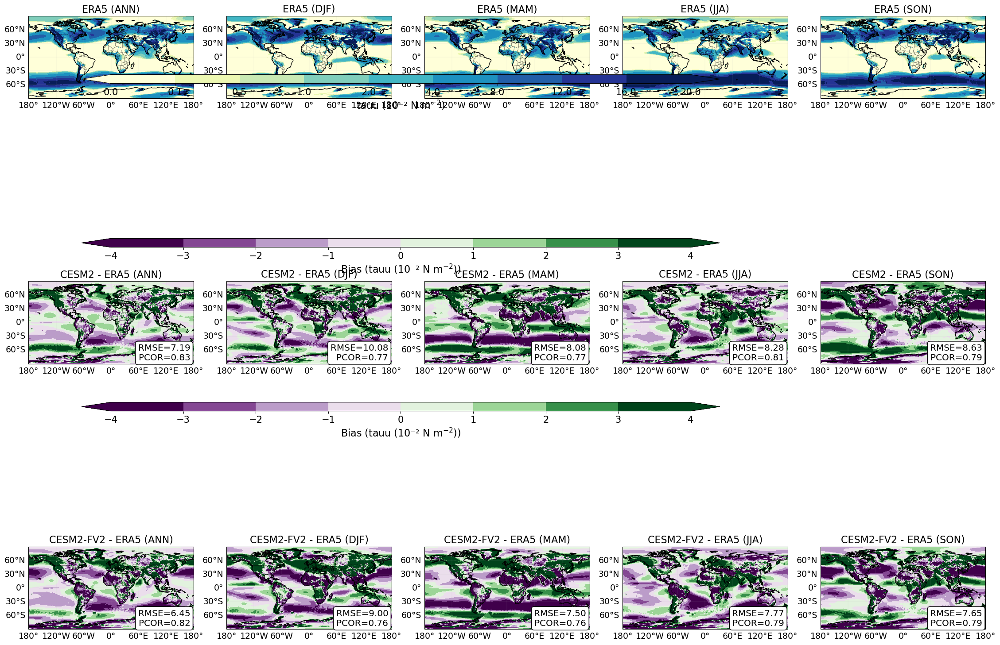

[INFO] Saved ./amip_model_vs_obs_1985-2014/tau_bias_grid_tauv.png


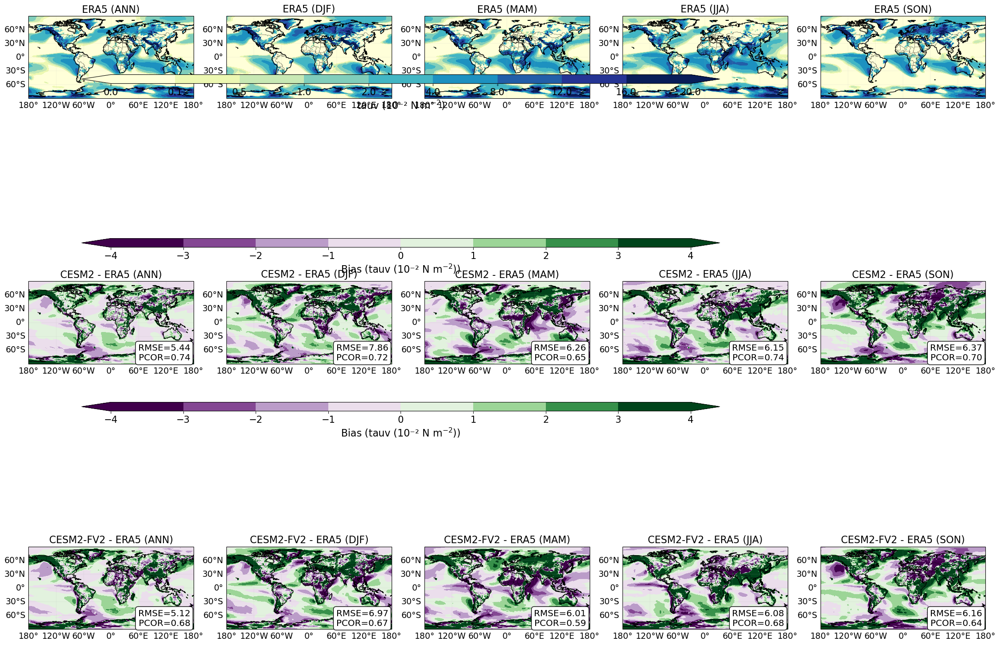

[INFO] Saved ./amip_model_vs_obs_1985-2014/tau_bias_grid_tau_mag.png


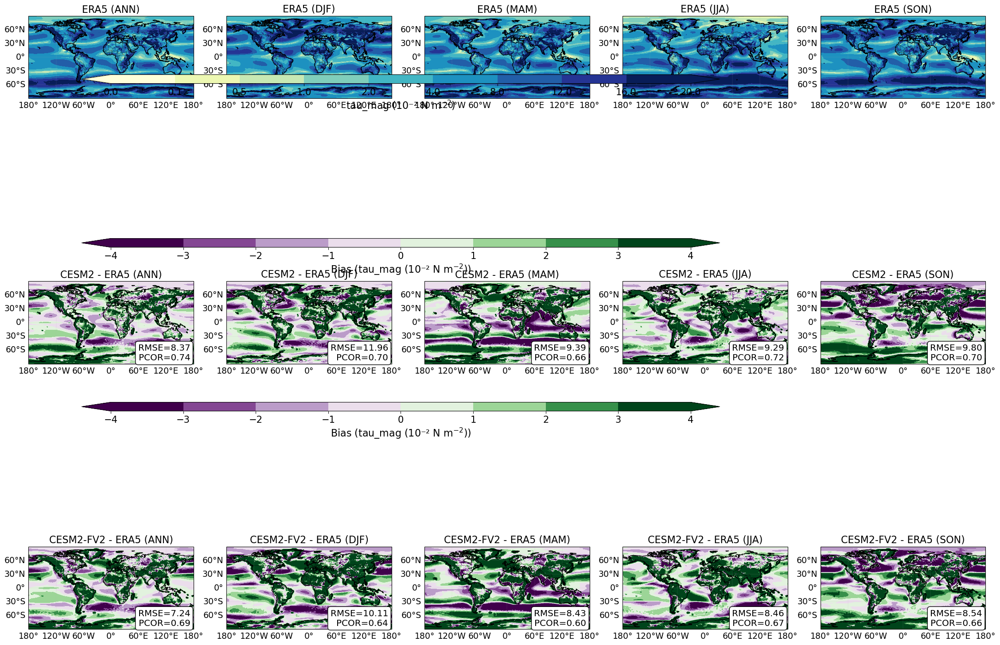

In [4]:
if __name__ == "__main__":
    outdir = "./amip_model_vs_obs_1985-2014"
    ref_name = "ERA5"

    exp_dict={
        'ERA5':{
            'tauu':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/observations/clim/v20240701/tauu/observations.historical.ERA5.en00.mon.tauu.198501-201412.AC.v20240701.nc',
            'tauv':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/observations/clim/v20240701/tauv/observations.historical.ERA5.en00.mon.tauv.198501-201412.AC.v20240701.nc'
        },
        'CESM2':{
            'tauu':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/clim/cmip6/amip/v20240701/tauu/cmip6.amip.CESM2.en00.mon.tauu.198501-201412.AC.v20240701.nc',
            'tauv':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/clim/cmip6/amip/v20240701/tauv/cmip6.amip.CESM2.en00.mon.tauv.198501-201412.AC.v20240701.nc',
        },
        'CESM2-FV2':{
            'tauu':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/clim/cmip6/amip/v20240701/tauu/cmip6.amip.CESM2-FV2.en00.mon.tauu.198501-201412.AC.v20240701.nc',
            'tauv':'/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/clim/cmip6/amip/v20240701/tauv/cmip6.amip.CESM2-FV2.en00.mon.tauv.198501-201412.AC.v20240701.nc'
        }
    }

    var_range_dict = {
        'tauu': {
            'raw_levels':  [0.0, 0.1, 0.5, 1, 2, 4, 8, 12, 16, 20],
            'diff_levels': [-4.0, -3.0, -2.0, -1.0, 0, 1.0, 2.0, 3.0, 4.0]
        },
        'tauv': {
            'raw_levels':  [0.0, 0.1, 0.5, 1, 2, 4, 8, 12, 16, 20],
            'diff_levels': [-4.0, -3.0, -2.0, -1.0, 0, 1.0, 2.0, 3.0, 4.0]
        },
        'tau_mag': {
            'raw_levels':  [0.0, 0.1, 0.5, 1, 2, 4, 8, 12, 16, 20],
            'diff_levels': [-4.0, -3.0, -2.0, -1.0, 0, 1.0, 2.0, 3.0, 4.0]
        }
    }

    plotter = TauClimatologyPlotter(exp_dict, save_dir=outdir, ref_name=ref_name)

    for var in var_range_dict.keys():
        vr = var_range_dict[var]
        plotter.plot_variable(
            var_name=var,
            cmap1='YlGnBu', #'viridis',
            cmap2='PRGn',#'RdBu_r',
            levels1=vr['raw_levels'],
            levels2=vr['diff_levels'],
            fontz=16,  # <-- control font size for all labels and colorbars
            fig_size = (24,20)
        )